# Tensorflow keras hometask

In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd

## Load data function

In [28]:
def load_dataset():
    fn = 'supplementary_data/train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:])
    Y_train = np.array(train_dataset["train_set_y"][:])
    
    fn = 'supplementary_data/test_signs.h5'
    test_dataset = h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:])
    Y_test = np.array(test_dataset["test_set_y"][:])
    
    classes = np.array(test_dataset["list_classes"][:])
    
    Y_train = Y_train.reshape((1, Y_train.shape[0]))
    Y_test = Y_test.reshape((1, Y_test.shape[0]))
    
    return X_train, Y_train, X_test, Y_test, classes

## Load data

In [29]:
train_data, train_labels, test_data, test_labels, classes = load_dataset()

X_train_norm = train_data / 255.0
X_test_norm = test_data / 255.0
Y_train_norm = train_labels.T
Y_test_norm = test_labels.T

## Base model

In [30]:
model_base = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(6, activation='softmax')
])

model_base.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

history_base = model_base.fit(X_train_norm, Y_train_norm, epochs=50, validation_data=(X_test_norm, Y_test_norm), verbose=1)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.1944 - loss: 2.1507 - val_accuracy: 0.2667 - val_loss: 1.7587
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2343 - loss: 1.7575 - val_accuracy: 0.2583 - val_loss: 1.7198
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.2731 - loss: 1.7116 - val_accuracy: 0.3750 - val_loss: 1.6825
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3306 - loss: 1.6620 - val_accuracy: 0.2500 - val_loss: 1.6563
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3120 - loss: 1.6614 - val_accuracy: 0.4167 - val_loss: 1.6021
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3435 - loss: 1.6336 - val_accuracy: 0.3750 - val_loss: 1.6191
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3731 - loss: 1.6154 - val_accuracy: 0.4333 - val_loss: 1.5949
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4028 - loss: 1.5980 - val_accuracy: 0.4500 - v

## Deep model

In [31]:
model_deep = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

model_deep.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

history_deep = model_deep.fit(X_train_norm, Y_train_norm, epochs=50, validation_data=(X_test_norm, Y_test_norm), verbose=1)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.1796 - loss: 1.9263 - val_accuracy: 0.2417 - val_loss: 1.7760
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1944 - loss: 1.8167 - val_accuracy: 0.2750 - val_loss: 1.7606
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2231 - loss: 1.7910 - val_accuracy: 0.1667 - val_loss: 1.7716
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2056 - loss: 1.7898 - val_accuracy: 0.2333 - val_loss: 1.7791
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2148 - loss: 1.7781 - val_accuracy: 0.1750 - val_loss: 1.7497
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2352 - loss: 1.7478 - val_accuracy: 0.2583 - val_loss: 1.7309
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2231 - loss: 1.7462 - val_accuracy: 0.2833 - val_loss: 1.7146
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2657 - loss: 1.7233 - val_accuracy: 0.3167 - v

## Model with tanh activation

In [32]:
model_tanh = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(256, activation='tanh'),
    Dropout(0.2),
    Dense(128, activation='tanh'),
    Dropout(0.2),
    Dense(64, activation='tanh'),
    Dense(6, activation='softmax')
])

model_tanh.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

history_tanh = model_tanh.fit(X_train_norm, Y_train_norm, epochs=50, validation_data=(X_test_norm, Y_test_norm), verbose=1)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.1722 - loss: 1.9188 - val_accuracy: 0.1667 - val_loss: 1.7848
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1907 - loss: 1.8323 - val_accuracy: 0.1667 - val_loss: 1.7856
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1833 - loss: 1.8337 - val_accuracy: 0.1667 - val_loss: 1.7665
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1759 - loss: 1.8255 - val_accuracy: 0.1833 - val_loss: 1.7619
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1889 - loss: 1.8078 - val_accuracy: 0.1917 - val_loss: 1.7539
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1861 - loss: 1.8188 - val_accuracy: 0.2083 - val_loss: 1.7392
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2046 - loss: 1.8020 - val_accuracy: 0.2250 - val_loss: 1.7188
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2278 - loss: 1.7789 - val_accuracy: 0.3250 - v

## Model whithout dropout

In [ ]:
model_no_dropout = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

model_no_dropout.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

history_no_dropout = model_no_dropout.fit(X_train_norm, Y_train_norm, epochs=50, validation_data=(X_test_norm, Y_test_norm), verbose=1)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.1880 - loss: 1.8384 - val_accuracy: 0.2667 - val_loss: 1.7905
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3009 - loss: 1.7110 - val_accuracy: 0.4000 - val_loss: 1.6062
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3556 - loss: 1.6376 - val_accuracy: 0.3250 - val_loss: 1.7085
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4287 - loss: 1.5456 - val_accuracy: 0.5250 - val_loss: 1.4590
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4954 - loss: 1.4230 - val_accuracy: 0.5417 - val_loss: 1.3934
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4815 - loss: 1.3880 - val_accuracy: 0.4333 - val_loss: 1.4285
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5037 - loss: 1.3524 - val_accuracy: 0.5333 - val_loss: 1.2900
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5435 - loss: 1.2714 - val_accuracy: 0.5667 - v

## Results

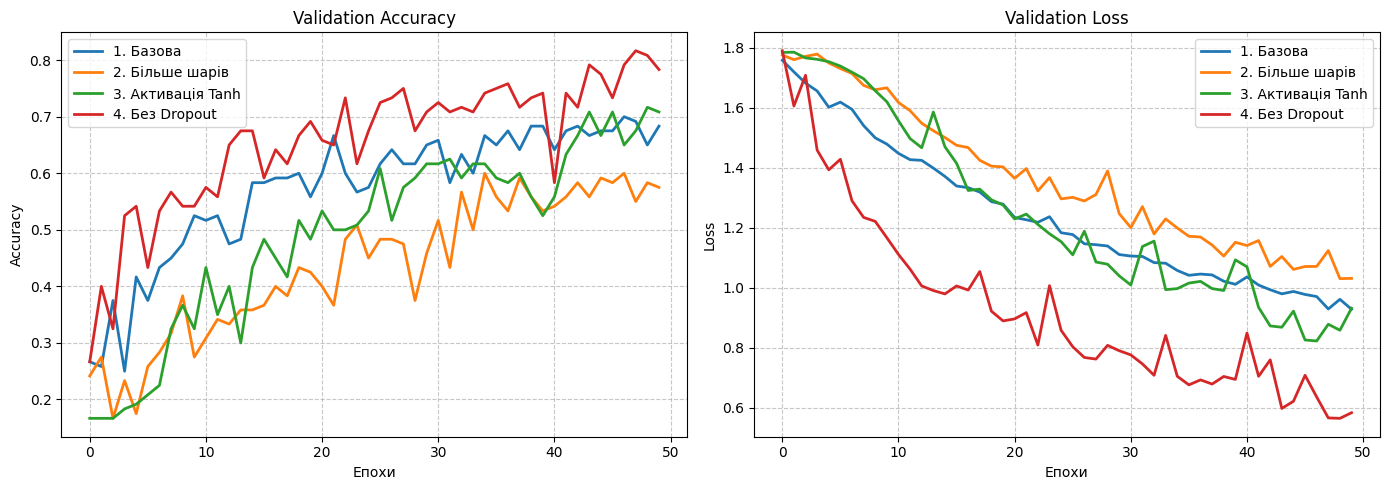


| Модель                    | Точність (Train) | Точність (Test) |
| 1. Базова                 |       67.31%      |      68.33%      |
| 2. Більше шарів           |       53.80%      |      57.50%      |
| 3. Активація Tanh         |       61.76%      |      70.83%      |
| 4. Без Dropout            |       88.06%      |      78.33%      |


In [35]:
histories = {
    "1. Базова": history_base,
    "2. Більше шарів": history_deep,
    "3. Активація Tanh": history_tanh,
    "4. Без Dropout": history_no_dropout
}

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=name, linewidth=2)
plt.title('Validation Accuracy')
plt.xlabel('Епохи')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
for name, hist in histories.items():
    plt.plot(hist.history['val_loss'], label=name, linewidth=2)
plt.title('Validation Loss')
plt.xlabel('Епохи')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(f"| {'Модель':<25} | {'Точність (Train)':<16} | {'Точність (Test)':<15} |")
print("="*70)

for name, hist in histories.items():
    # Беремо значення з останньої (50-ї) епохи
    train_acc = hist.history['accuracy'][-1] * 100
    val_acc = hist.history['val_accuracy'][-1] * 100
    
    print(f"| {name:<25} | {train_acc:>11.2f}%      | {val_acc:>10.2f}%      |")
    
print("="*70)

## Висновок

Як можна побачити з результатів, модель без Dropout (0.0) показала найкращі результати як на тренувальних, так і на тестових даних. Але також можна сказати що ця моделька з великою вірогідністю перенавчилася. 

Оптимальним варіантом є Базова модель, яка показала хорошу точність на тестових даних і не перенавчилася.